# Master Shear-Wave Splitting Workflow for Axial Seamount

This notebook provides a complete, clean workflow from raw earthquake catalog and waveform data to shear-wave splitting analysis results. The workflow follows proper sequencing and includes all necessary quality control measures.

## Workflow Overview

1. **Data Loading & Initial Setup** - Load earthquake catalog and station metadata
2. **Extended Time Window Creation** - Create proper time windows for waveform retrieval
3. **Waveform Data Retrieval** - Download seismic data with extended windows
4. **Quality Control Filters** - P-wave rectilinearity, SNR, and incidence angle filtering
5. **Geometric Calculations** - Back-azimuth and distance calculations
6. **Shear-Wave Splitting Analysis** - Dynamic parameter estimation and SWSPy analysis
7. **Results Processing & Visualization** - Compile and visualize splitting parameters

## Key Improvements
- Extended catalog creation moved to proper early position
- Updated P-wave polarization analysis for true incidence angles
- Integrated SNR calculations with proper S-wave timing
- Clean separation of quality control steps

## 1. Import Requirements

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.core.utcdatetime import UTCDateTime
from obspy.clients.fdsn import Client
import os
import sys
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add local swspy directory to path (before other imports)
swspy_local_path = os.path.abspath('../swspy')
if swspy_local_path not in sys.path:
    sys.path.insert(0, swspy_local_path)

# Import swspy from local directory
import swspy

# Add scripts directory to path for custom modules
sys.path.append('.')
from seismic_geometry import (calculate_back_azimuth, calculate_epicentral_distance_km)
from get_all_traces import get_station_traces
from splitting_functions import *

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")
print(f"ObsPy version: {obspy.__version__}")
print(f"SWSPy available: {'Yes' if 'swspy' in sys.modules else 'No'}")
print(f"SWSPy location: {swspy.__file__}")

mtspec not available, using ObsPy PPSD method
Libraries imported successfully
ObsPy version: 1.4.2
SWSPy available: Yes
SWSPy location: /Users/mhemmett/Seismology/Axial_Splitting/swspy/swspy/__init__.py


## 2. Raw Data Organization

First, we need to process the raw phase pick data to create a structured catalog where each row represents one event at a single station with both P- and S-wave arrival times.

In [2]:
# Parse raw phase pick data and create organized catalog

# Load and parse the raw phase pick data
print("Loading raw phase pick data from Axial Seamount...")

# Parse the phase file
#phase_file = '../data/ax.hinv.pha.shots_erup' #- ML DD catalog
phase_file = '../data/old_catalog_erup' # - Day 1 of old catalog (what Christian used)
events_df, phases_df = parse_phase_file(phase_file)

print(f"\nParsed {len(events_df)} events and {len(phases_df)} phase picks")
print(f"Date range: {events_df['year'].min()}-{events_df['year'].max()}")

# Display sample of parsed data
print(f"\nSample events:")
display(events_df.head())

print(f"\nSample phases:")
display(phases_df.head())

# Create organized catalog structure
raw_catalog = create_organized_catalog(events_df, phases_df)

print(f"\nOrganized catalog created with {len(raw_catalog)} event-station pairs")
print(f"Events: {raw_catalog['id'].nunique()}, Stations: {raw_catalog['station'].nunique()}")

# Display sample of organized catalog
print(f"\nSample of organized catalog:")
display(raw_catalog.head())

Loading raw phase pick data from Axial Seamount...
Parsing phase file: ../data/old_catalog_erup
Processing 800 lines...

Parsed 67 events and 732 phase picks
Date range: 2015-2015

Sample events:


,event_id,year,month,day,hour,minute,second,datetime_str,lat,lon,depth,magnitude
0,0.033,2015,1,22,0,0,27.537,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3
1,0.093,2015,1,22,0,8,58.891,2015-01-22T00:08:58.891Z,45.94934,-129.99501,0.000,0.0
2,0.030,2015,1,22,2,2,41.042,2015-01-22T02:02:41.042Z,45.94109,-130.01480,0.675,-0.0
3,0.065,2015,1,22,2,19,56.897,2015-01-22T02:19:56.897Z,45.91550,-129.95985,1.598,0.3
4,0.058,2015,1,22,2,36,7.075,2015-01-22T02:36:07.075Z,45.94662,-129.99509,0.509,-0.1



Sample phases:


,event_id,event_datetime,event_lat,event_lon,event_depth,event_magnitude,station,arrival_time,weight,phase_type,quality
0,0.033,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXCC1,0.424,1.00,P,
1,0.033,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC1,0.619,0.50,P,
2,0.033,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC2,0.664,0.75,P,
3,0.033,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXCC1,1.209,0.25,S,
4,0.033,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC1,0.979,0.25,S,


Creating organized catalog with events × stations structure...
Events: 49, Stations: 7
Stations in network: ['AXAS1', 'AXAS2', 'AXCC1', 'AXEC1', 'AXEC2', 'AXEC3', 'AXID1']
Total event-station pairs: 343
Pairs with both P and S picks: 255

Organized catalog created with 255 event-station pairs
Events: 49, Stations: 7

Sample of organized catalog:


,id,year,datetime,lat,lon,dep,mag,station,total_picks,p_arrival_time,p_weight,p_quality,s_arrival_time,s_weight,s_quality
0,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXCC1,6,0.424,1.00,,1.209,0.25,
1,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC1,6,0.619,0.50,,0.979,0.25,
2,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC2,6,0.664,0.75,,1.349,0.25,
3,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC3,5,0.919,1.00,,1.474,0.08,
4,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXAS1,4,0.579,1.00,,1.294,0.08,


In [6]:
# Edit catalog to only include data beginning January 22, 2015
# Also remove unnecessary columns: total_picks, p_weight, p_quality, s_weight, s_quality, and index

start_date = UTCDateTime("2015-01-22T00:00:00")

edited_catalog = raw_catalog[raw_catalog['datetime'] >= start_date].copy()
edited_catalog = edited_catalog.drop(columns=['total_picks', 'p_weight', 
                                              'p_quality', 's_weight', 's_quality'])

edited_catalog.reset_index(drop=True, inplace=True)

In [7]:
# Use the organized catalog created from raw phase picks
print("Using organized catalog created from raw phase pick data...")

# Set catalog as our working dataset
catalog = edited_catalog.copy()

print(f"Working catalog has {len(catalog)} event-station pairs")
print(f"Date range: {catalog['datetime'].min()} to {catalog['datetime'].max()}")

# Display basic catalog info
print("\nCatalog columns:", catalog.columns.tolist())
print("\nFirst few events:")
display(catalog.head())


Using organized catalog created from raw phase pick data...
Working catalog has 255 event-station pairs
Date range: 2015-01-22T00:00:27.537Z to 2015-01-22T23:22:32.553Z

Catalog columns: ['id', 'year', 'datetime', 'lat', 'lon', 'dep', 'mag', 'station', 'p_arrival_time', 's_arrival_time']

First few events:


,id,year,datetime,lat,lon,dep,mag,station,p_arrival_time,s_arrival_time
0,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXCC1,0.424,1.209
1,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC1,0.619,0.979
2,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC2,0.664,1.349
3,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXEC3,0.919,1.474
4,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXAS1,0.579,1.294


In [8]:
# Save formatted old catalog to csv
catalog.to_csv('2015_01_22_old_catalog.csv')

In [ ]:
###################################################################

In [2]:
# Load 2018 earthquake test catalog - ML DD
#catalog = pd.read_csv('2018_eq_catalog.csv')

# Load day 1 of old catalog - before DD relocation
catalog = pd.read_csv('2015_01_22_old_catalog.csv')

# Load station information
stations_file = '../data/axial_seamount_stations.csv'
stations_df = pd.read_csv(stations_file)

print(f"Stations in catalog: {catalog['station'].value_counts()}")

Stations in catalog: station
AXEC1    46
AXEC2    46
AXCC1    44
AXEC3    42
AXAS1    30
AXAS2    30
AXID1    17
Name: count, dtype: int64


In [3]:
stations_df

,Station ID,Location Name,Latitude (°N),Longitude (°W),Elevation (m)
0,AXAS1,Axial Ashes 1,45.936,-130.013,-1516
1,AXAS2,Axial Ashes 2,45.936,-130.013,-1516
2,AXBA1,Axial Base 1,45.550,-130.000,-2600
3,AXCC1,Axial Central Caldera 1,45.955,-130.008,-1516
4,AXEC1,Axial East Caldera 1,45.955,-129.973,-1519
5,AXEC2,Axial East Caldera 2,45.955,-129.973,-1519
6,AXEC3,Axial East Caldera 3,45.955,-129.973,-1519
7,AXID1,Axial International,45.934,-130.004,-1512


## 3. Extended Time Window Creation

This step creates extended time windows for waveform retrieval. This is critical for proper analysis and must happen early in the workflow, before any quality control that depends on waveform data.

In [4]:
# Create extended time windows for proper waveform analysis
print("Creating extended time windows for waveform retrieval...")

# Apply extended windowing
extended_catalog = create_extended_catalog(catalog, pre_event_time=4.0, post_event_time=15.0)

print(f"Extended catalog created with {len(extended_catalog)} events")
print(f"Time windows: {extended_catalog['total_duration'].iloc[0]} seconds total")
print(f"Pre-event: {extended_catalog['pre_event_sec'].iloc[0]}s, Post-event: {extended_catalog['post_event_sec'].iloc[0]}s")

# Display sample of extended timing
print("\nSample timing windows:")
sample_cols = ['id', 'datetime', 'starttime', 'endtime', 'total_duration']
display(extended_catalog[sample_cols].head())

Creating extended time windows for waveform retrieval...
Extended catalog created with 255 events
Time windows: 19.0 seconds total
Pre-event: 4.0s, Post-event: 15.0s

Sample timing windows:


,id,datetime,starttime,endtime,total_duration
0,0.033,2015-01-22T00:00:27.537Z,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,19.0
1,0.033,2015-01-22T00:00:27.537Z,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,19.0
2,0.033,2015-01-22T00:00:27.537Z,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,19.0
3,0.033,2015-01-22T00:00:27.537Z,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,19.0
4,0.033,2015-01-22T00:00:27.537Z,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,19.0


In [5]:
# Remove leading 'OO' from station names
extended_catalog['station'] = extended_catalog['station'].str.replace('OO', '', regex=False)

In [6]:
# Keep just the data from station AXAS2
filtered_catalog = extended_catalog[extended_catalog['station'] == 'AXAS2'].copy()

In [7]:
# Keep only events up until 2017-02-12T15:02:12.095000Z
cutoff_date = UTCDateTime("2017-02-12T15:02:12.095000Z")
filtered_catalog = filtered_catalog[filtered_catalog['datetime'] <= cutoff_date].copy()

# Keep events with depth > 0 km
filtered_catalog = filtered_catalog[filtered_catalog['dep'] > 0].copy()

In [8]:
# Reset index
filtered_catalog.reset_index(drop=True, inplace=True)

In [9]:
##########################
# Test: subtract 1.525 from dep column in filtered_catalog, then remove all rows with negative depth

In [10]:
filtered_catalog

,Unnamed: 0,id,year,datetime,lat,lon,dep,mag,station,p_arrival_time,s_arrival_time,starttime,endtime,origin_utc,pre_event_sec,post_event_sec,total_duration
0,5,0.033,2015,2015-01-22T00:00:27.537Z,45.94689,-129.99863,0.547,-0.3,AXAS2,0.329,0.604,2015-01-22T00:00:23.537000Z,2015-01-22T00:00:42.537000Z,2015-01-22T00:00:27.537000Z,4.0,15.0,19.0
1,18,0.030,2015,2015-01-22T02:02:41.042Z,45.94109,-130.01480,0.675,-0.0,AXAS2,0.358,0.583,2015-01-22T02:02:37.042000Z,2015-01-22T02:02:56.042000Z,2015-01-22T02:02:41.042000Z,4.0,15.0,19.0
2,32,0.079,2015,2015-01-22T02:39:20.658Z,45.94880,-129.99129,1.562,0.1,AXAS2,0.682,1.337,2015-01-22T02:39:16.658000Z,2015-01-22T02:39:35.658000Z,2015-01-22T02:39:20.658000Z,4.0,15.0,19.0
3,38,0.055,2015,2015-01-22T02:42:34.062Z,45.94497,-129.98904,1.088,0.3,AXAS2,0.698,1.243,2015-01-22T02:42:30.062000Z,2015-01-22T02:42:49.062000Z,2015-01-22T02:42:34.062000Z,4.0,15.0,19.0
4,44,0.028,2015,2015-01-22T02:50:15.943Z,45.96606,-129.99217,1.447,0.5,AXAS2,0.997,1.687,2015-01-22T02:50:11.943000Z,2015-01-22T02:50:30.943000Z,2015-01-22T02:50:15.943000Z,4.0,15.0,19.0
5,51,0.072,2015,2015-01-22T02:59:40.845Z,45.94606,-129.98662,1.305,0.3,AXAS2,0.750,1.345,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:55.845000Z,2015-01-22T02:59:40.845000Z,4.0,15.0,19.0
6,57,0.152,2015,2015-01-22T03:00:46.773Z,45.93476,-130.01872,1.226,0.4,AXAS2,0.367,0.592,2015-01-22T03:00:42.773000Z,2015-01-22T03:01:01.773000Z,2015-01-22T03:00:46.773000Z,4.0,15.0,19.0
7,64,0.087,2015,2015-01-22T03:01:31.650Z,45.95464,-129.99290,1.117,0.3,AXAS2,0.780,1.250,2015-01-22T03:01:27.650000Z,2015-01-22T03:01:46.650000Z,2015-01-22T03:01:31.650000Z,4.0,15.0,19.0
8,70,0.070,2015,2015-01-22T03:21:07.809Z,45.93618,-130.01025,0.770,-0.2,AXAS2,0.371,0.386,2015-01-22T03:21:03.809000Z,2015-01-22T03:21:22.809000Z,2015-01-22T03:21:07.809000Z,4.0,15.0,19.0
9,80,0.034,2015,2015-01-22T03:37:40.683Z,45.94294,-130.01294,0.617,0.1,AXAS2,0.427,0.647,2015-01-22T03:37:36.683000Z,2015-01-22T03:37:55.683000Z,2015-01-22T03:37:40.683000Z,4.0,15.0,19.0


## 4. Waveform Data Retrieval

This section retrieves seismic waveform data using the extended time windows. We'll load the existing trace data and organize it for processing.

In [11]:
test_catalog = filtered_catalog.head(10)

In [12]:
#########################

In [13]:
# Retrieve waveforms for all events in the test catalog using get_all_traces function
print("Retrieving waveforms for all events in the test catalog...")
waveforms = get_station_traces(test_catalog, 'first_event', 'starttime', 'endtime', 'station')

Retrieving waveforms for all events in the test catalog...
Retrieved data for AXAS2 EHE from 2015-01-22T00:00:23.537000Z to 2015-01-22T00:00:42.537000Z
Retrieved data for AXAS2 EHN from 2015-01-22T00:00:23.537000Z to 2015-01-22T00:00:42.537000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T00:00:23.537000Z to 2015-01-22T00:00:42.537000Z
Retrieved data for AXAS2 EHE from 2015-01-22T02:02:37.042000Z to 2015-01-22T02:02:56.042000Z
Retrieved data for AXAS2 EHN from 2015-01-22T02:02:37.042000Z to 2015-01-22T02:02:56.042000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T02:02:37.042000Z to 2015-01-22T02:02:56.042000Z
Retrieved data for AXAS2 EHE from 2015-01-22T02:39:16.658000Z to 2015-01-22T02:39:35.658000Z
Retrieved data for AXAS2 EHN from 2015-01-22T02:39:16.658000Z to 2015-01-22T02:39:35.658000Z
Retrieved data for AXAS2 EHZ from 2015-01-22T02:39:16.658000Z to 2015-01-22T02:39:35.658000Z
Retrieved data for AXAS2 EHE from 2015-01-22T02:42:30.062000Z to 2015-01-22T02:42:49.062000Z
Retrieved d

In [14]:
# Associate waveforms with events in the catalog
print("Organizing waveforms by events...")
waveform_dict = organize_stream_by_events(waveforms, test_catalog)

Organizing waveforms by events...
Organizing stream data for 10 events...
  Event 1: Found 3 traces for AXAS2 at 2015-01-22T00:00:27.537000Z
  Event 2: Found 3 traces for AXAS2 at 2015-01-22T02:02:41.042000Z
  Event 3: Found 3 traces for AXAS2 at 2015-01-22T02:39:20.658000Z
  Event 4: Found 3 traces for AXAS2 at 2015-01-22T02:42:34.062000Z
  Event 5: Found 3 traces for AXAS2 at 2015-01-22T02:50:15.943000Z
  Event 6: Found 3 traces for AXAS2 at 2015-01-22T02:59:40.845000Z
  Event 7: Found 3 traces for AXAS2 at 2015-01-22T03:00:46.773000Z
  Event 8: Found 3 traces for AXAS2 at 2015-01-22T03:01:31.650000Z
  Event 9: Found 3 traces for AXAS2 at 2015-01-22T03:21:07.809000Z
  Event 10: Found 3 traces for AXAS2 at 2015-01-22T03:37:40.683000Z


In [15]:
# Replace catalog id with index
test_catalog['id'] = test_catalog.index

In [16]:
# Organize waveforms by event ID
print("Organizing waveforms by event ID...")
organized_waveforms = organize_waveform_data(waveform_dict, test_catalog)

Organizing waveforms by event ID...


In [17]:
organized_waveforms

{0: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHN | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHZ | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples,
  'origin_time': 2015-01-22T00:00:27.537000Z,
  'datetime': '2015-01-22T00:00:27.537Z',
  'starttime': 2015-01-22T00:00:23.537000Z,
  'endtime': 2015-01-22T00:00:42.537000Z,
  'pre_event_sec': 4.0,
  'post_event_sec': 15.0,
  'magnitude': -0.3,
  'depth': 0.547,
  'latitude': 45.94689,
  'longitude': -129.99863,
  'station': 'AXAS2',
  'p_arrival_time': 0.329,
  's_arrival_time': 0.604},
 1: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T02:02:37.045000Z - 2015-01-22T02:02:56.040000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHN | 2015-01-22T02:02:37.045000Z - 2015-01-22T02:02:56.040000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHZ | 2015-01-22T02:02:37.045

In [18]:
organized_waveforms

{0: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHN | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHZ | 2015-01-22T00:00:23.540000Z - 2015-01-22T00:00:42.535000Z | 200.0 Hz, 3800 samples,
  'origin_time': 2015-01-22T00:00:27.537000Z,
  'datetime': '2015-01-22T00:00:27.537Z',
  'starttime': 2015-01-22T00:00:23.537000Z,
  'endtime': 2015-01-22T00:00:42.537000Z,
  'pre_event_sec': 4.0,
  'post_event_sec': 15.0,
  'magnitude': -0.3,
  'depth': 0.547,
  'latitude': 45.94689,
  'longitude': -129.99863,
  'station': 'AXAS2',
  'p_arrival_time': 0.329,
  's_arrival_time': 0.604},
 1: {'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T02:02:37.045000Z - 2015-01-22T02:02:56.040000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHN | 2015-01-22T02:02:37.045000Z - 2015-01-22T02:02:56.040000Z | 200.0 Hz, 3800 samples
OO.AXAS2..EHZ | 2015-01-22T02:02:37.045

## 5. Quality Control Pipeline

This section implements comprehensive quality control measures including P-wave rectilinearity analysis, signal-to-noise ratio calculations, and incidence angle filtering.

In [19]:
# Define quality control thresholds
QC_THRESHOLDS = {
    'min_snr': 2.0,           # Minimum S-wave signal-to-noise ratio
    'min_rectilinearity': 0.7, # Minimum P-wave rectilinearity
    'max_incidence': 30.0,     # Maximum incidence angle (degrees)
    'min_magnitude': 0.0,      # Minimum event magnitude
}

print("Quality control functions loaded successfully")
print(f"QC Thresholds: {QC_THRESHOLDS}")

Quality control functions loaded successfully
QC Thresholds: {'min_snr': 2.0, 'min_rectilinearity': 0.7, 'max_incidence': 30.0, 'min_magnitude': 0.0}


In [20]:
organized_waveforms[0]['p_arrival_time']

0.329

In [21]:
# Calculate quality control metrics for organized waveforms
print("Calculating quality control metrics for organized waveforms...")

# 1. Calculate S-wave SNR
organized_waveforms = calculate_snr_for_organized_waveforms(organized_waveforms)

# 2. Calculate geographic back-azimuth, for coordinate rotation later
organized_waveforms = calculate_back_azimuth_for_organized_waveforms(organized_waveforms, stations_df)

# 3. Calculate incidence angle
#organized_waveforms = calculate_incidence_angle_for_organized_waveforms(organized_waveforms, stations_df)

organized_waveforms = calculate_incidence_angle_eigenvalue_jurkevics_for_organized_waveforms(organized_waveforms, stations_df)

#4. Calculate P-wave rectilinearity
organized_waveforms = calculate_rectilinearity_jurkevics_for_organized_waveforms(organized_waveforms, p_arrival_variable='p_arrival_time', analysis_window=0.5)

Calculating quality control metrics for organized waveforms...
Calculating SNR for 10 events in organized_waveforms...

Processing event 0...
  Found 3 traces for this event

  Calculating SNR for E component:
  S-pick time: 2015-01-22T00:00:28.141000Z
  S-P delay: 0.27s
  Found E trace: 2015-01-22T00:00:23.540000Z to 2015-01-22T00:00:42.535000Z
  Noise window: 2015-01-22T00:00:27.741000Z to 2015-01-22T00:00:28.141000Z (0.40s)
  Signal window: 2015-01-22T00:00:28.141000Z to 2015-01-22T00:00:28.341000Z (0.20s)
  Noise data points: 81
  Signal data points: 41
  Noise RMS: 13.925507
  Signal RMS: 9.047576
  SNR: 0.65

  Calculating SNR for N component:
  S-pick time: 2015-01-22T00:00:28.141000Z
  S-P delay: 0.27s
  Found N trace: 2015-01-22T00:00:23.540000Z to 2015-01-22T00:00:42.535000Z
  Noise window: 2015-01-22T00:00:27.741000Z to 2015-01-22T00:00:28.141000Z (0.40s)
  Signal window: 2015-01-22T00:00:28.141000Z to 2015-01-22T00:00:28.341000Z (0.20s)
  Noise data points: 81
  Signal data

In [22]:
# Create a dataframe with quality control metrics for the test catalog events
qc_metrics_df = pd.DataFrame({
    'event_id': list(organized_waveforms.keys()),
    's_time': [(UTCDateTime(organized_waveforms[eid]['datetime']) + organized_waveforms[eid]['s_arrival_time']) for eid in organized_waveforms.keys()],
    'station': [organized_waveforms[eid]['station'] for eid in organized_waveforms.keys()],
    'back_azimuth': [organized_waveforms[eid]['back_azimuth'] for eid in organized_waveforms.keys()],
    'snr_horizontal': [organized_waveforms[eid]['snr_horizontal'] for eid in organized_waveforms.keys()],
    'incidence': [organized_waveforms[eid]['incidence_eigenvalue_jurkevics'] for eid in organized_waveforms.keys()],
    'rectilinearity': [organized_waveforms[eid]['rectilinearity_jurkevics'] for eid in organized_waveforms.keys()],
    'latitude': [organized_waveforms[eid]['latitude'] for eid in organized_waveforms.keys()],
    'longitude': [organized_waveforms[eid]['longitude'] for eid in organized_waveforms.keys()],
    'depth': [organized_waveforms[eid]['depth'] for eid in organized_waveforms.keys()]
})

print(f"Quality control metrics dataframe created with {len(qc_metrics_df)} events")
display(qc_metrics_df)

Quality control metrics dataframe created with 10 events


,event_id,s_time,station,back_azimuth,snr_horizontal,incidence,rectilinearity,latitude,longitude,depth
0,0,2015-01-22T00:00:28.141000Z,AXAS2,47.238033,0.870423,87.820358,0.806503,45.94689,-129.99863,0.547
1,1,2015-01-22T02:02:41.625000Z,AXAS2,103.919455,5.425074,33.825244,0.880677,45.94109,-130.01480,0.675
2,2,2015-01-22T02:39:21.995000Z,AXAS2,40.073297,1.298310,82.169185,0.828911,45.94880,-129.99129,1.562
3,3,2015-01-22T02:42:35.305000Z,AXAS2,28.110759,1.425851,56.170526,0.653776,45.94497,-129.98904,1.088
4,4,2015-01-22T02:50:17.630000Z,AXAS2,64.097226,2.440639,72.770432,0.892002,45.96606,-129.99217,1.447
5,5,2015-01-22T02:59:42.190000Z,AXAS2,28.552600,1.740068,66.642383,0.473483,45.94606,-129.98662,1.305
6,6,2015-01-22T03:00:47.365000Z,AXAS2,197.188223,6.202452,62.317608,0.882371,45.93476,-130.01872,1.226
7,7,2015-01-22T03:01:32.900000Z,AXAS2,52.921069,4.730434,67.450857,0.955117,45.95464,-129.99290,1.117
8,8,2015-01-22T03:21:08.195000Z,AXAS2,5.335755,7.813176,15.993833,0.792846,45.93618,-130.01025,0.770
9,9,2015-01-22T03:37:41.330000Z,AXAS2,89.652850,4.950286,71.970546,0.923853,45.94294,-130.01294,0.617


In [23]:
# Load Christian's results for comparison
christian_df = pd.read_csv('../data/first_10_events_unfiltered_christian.csv')

# Filter Christian's dataframe to only include relevant columns
christian_filtered = christian_df[['s_time', 'station_code', 'baz_trigo_rad', 's_snr', 'inc_deg', 'rec', 'event_lat', 'event_lon', 'event_depth_km']]

# Rename columns for consistency
christian_filtered = christian_filtered.rename(columns={
    's_time': 's_time_christian',
    'station_code': 'station_christian',
    's_snr': 'snr_horizontal_christian',
    'inc_deg': 'incidence_christian',
    'rec': 'rectilinearity_christian',
    'event_lat': 'latitude_christian',
    'event_lon': 'longitude_christian',
    'event_depth_km': 'depth_christian'
})

# convert baz_trigo_rad to degrees, in a new column called back_azimuth_deg, and remvove baz_trigo_rad
christian_filtered['back_azimuth_christian'] = np.rad2deg(christian_filtered['baz_trigo_rad'])
christian_filtered = christian_filtered.drop(columns=['baz_trigo_rad'])

# Display Christian's results
print("Christian's results:")
display(christian_filtered)

Christian's results:


,s_time_christian,station_christian,snr_horizontal_christian,incidence_christian,rectilinearity_christian,latitude_christian,longitude_christian,depth_christian,back_azimuth_christian
0,2015-01-22T00:09:00.705000Z,AXAS2,3.386959,4.933158,0.948354,45.974004,-129.989863,2.05625,66.488794
1,2015-01-22T02:02:41.625000Z,AXAS2,4.586738,12.682831,0.905058,45.942963,-130.017317,0.74375,102.990577
2,2015-01-22T03:00:47.365000Z,AXAS2,4.360540,13.112185,0.983793,45.939859,-130.011032,0.35625,69.903142
3,2015-01-22T03:01:32.900000Z,AXAS2,5.228774,6.088902,0.767018,45.951005,-129.995591,0.60625,52.436660
4,2015-01-22T03:37:41.330000Z,AXAS2,3.071345,20.481152,0.909814,45.944162,-130.017822,1.01250,103.299938
5,2015-01-22T03:40:37.420000Z,AXAS2,2.507870,15.958202,0.967886,45.956508,-130.038201,0.09375,125.742832
6,2015-01-22T03:40:39.155000Z,AXAS2,2.810380,20.380819,0.922670,45.945079,-129.992356,0.05625,35.982159
7,2015-01-22T04:45:04.630000Z,AXAS2,4.487101,15.103704,0.991043,45.940847,-130.012451,0.40625,80.037901
8,2015-01-22T04:51:49.220000Z,AXAS2,3.216641,8.193960,0.944412,45.922998,-129.990674,0.01250,325.896936
9,2015-01-22T04:56:43.310000Z,AXAS2,5.840823,9.765236,0.973196,45.934639,-130.020778,1.43125,168.704738


In [24]:
# Round s_time and s_time_christian to nearest second for comparison, then combine dataframes on station and s_time
# Convert UTCDateTime objects to strings before using pd.to_datetime
qc_metrics_df['s_time_rounded'] = pd.to_datetime(qc_metrics_df['s_time'].astype(str)).dt.round('S')
christian_filtered['s_time_christian_rounded'] = pd.to_datetime(christian_filtered['s_time_christian']).dt.round('S')
# Merge dataframes on station and rounded s_time
comparison_df = pd.merge(qc_metrics_df, christian_filtered, left_on=['station', 's_time_rounded'], right_on=['station_christian', 's_time_christian_rounded'], how='inner')
print(f"Comparison dataframe created with {len(comparison_df)} matched events")
display(comparison_df)

Comparison dataframe created with 4 matched events


,event_id,s_time,station,back_azimuth,snr_horizontal,incidence,rectilinearity,latitude,longitude,depth,...,s_time_christian,station_christian,snr_horizontal_christian,incidence_christian,rectilinearity_christian,latitude_christian,longitude_christian,depth_christian,back_azimuth_christian,s_time_christian_rounded
0,1,2015-01-22T02:02:41.625000Z,AXAS2,103.919455,5.425074,33.825244,0.880677,45.94109,-130.01480,0.675,...,2015-01-22T02:02:41.625000Z,AXAS2,4.586738,12.682831,0.905058,45.942963,-130.017317,0.74375,102.990577,2015-01-22 02:02:42+00:00
1,6,2015-01-22T03:00:47.365000Z,AXAS2,197.188223,6.202452,62.317608,0.882371,45.93476,-130.01872,1.226,...,2015-01-22T03:00:47.365000Z,AXAS2,4.360540,13.112185,0.983793,45.939859,-130.011032,0.35625,69.903142,2015-01-22 03:00:47+00:00
2,7,2015-01-22T03:01:32.900000Z,AXAS2,52.921069,4.730434,67.450857,0.955117,45.95464,-129.99290,1.117,...,2015-01-22T03:01:32.900000Z,AXAS2,5.228774,6.088902,0.767018,45.951005,-129.995591,0.60625,52.436660,2015-01-22 03:01:33+00:00
3,9,2015-01-22T03:37:41.330000Z,AXAS2,89.652850,4.950286,71.970546,0.923853,45.94294,-130.01294,0.617,...,2015-01-22T03:37:41.330000Z,AXAS2,3.071345,20.481152,0.909814,45.944162,-130.017822,1.01250,103.299938,2015-01-22 03:37:41+00:00


In [25]:
# For each column, compare snr_horizontal vs. snr_horizontal_christian, incidence vs. incidence_christian, rectilinearity vs. rectilinearity_christian, and back_azimuth vs. back_azimuth_christian
# Calculate the differences and display summary statistics
comparison_metrics = ['snr_horizontal', 'incidence', 'rectilinearity', 'back_azimuth', 'latitude', 'longitude', 'depth']
for metric in comparison_metrics:
    col1 = metric
    col2 = f"{metric}_christian"
    comparison_df[f"{metric}_diff"] = comparison_df[col1] - comparison_df[col2]
    # Print differences for each event
    print(f"\nDifferences for {metric}:")
    display(comparison_df[['event_id', 'station', col1, col2, f"{metric}_diff"]])
    # Print summary statistics
    diff_stats = comparison_df[f"{metric}_diff"].describe()
    print(f"\nSummary statistics for {metric} differences:")
    print(diff_stats)


Differences for snr_horizontal:


,event_id,station,snr_horizontal,snr_horizontal_christian,snr_horizontal_diff
0,1,AXAS2,5.425074,4.586738,0.838336
1,6,AXAS2,6.202452,4.360540,1.841912
2,7,AXAS2,4.730434,5.228774,-0.498340
3,9,AXAS2,4.950286,3.071345,1.878941



Summary statistics for snr_horizontal differences:
count    4.000000
mean     1.015212
std      1.118270
min     -0.498340
25%      0.504167
50%      1.340124
75%      1.851169
max      1.878941
Name: snr_horizontal_diff, dtype: float64

Differences for incidence:


,event_id,station,incidence,incidence_christian,incidence_diff
0,1,AXAS2,33.825244,12.682831,21.142413
1,6,AXAS2,62.317608,13.112185,49.205423
2,7,AXAS2,67.450857,6.088902,61.361955
3,9,AXAS2,71.970546,20.481152,51.489394



Summary statistics for incidence differences:
count     4.000000
mean     45.799796
std      17.264001
min      21.142413
25%      42.189670
50%      50.347409
75%      53.957534
max      61.361955
Name: incidence_diff, dtype: float64

Differences for rectilinearity:


...


Summary statistics for latitude differences:
count    4.000000
mean    -0.001140
std      0.003606
min     -0.005099
25%     -0.002679
50%     -0.001547
75%     -0.000008
max      0.003635
Name: latitude_diff, dtype: float64

Differences for longitude:


,event_id,station,longitude,longitude_christian,longitude_diff
0,1,AXAS2,-130.01480,-130.017317,0.002517
1,6,AXAS2,-130.01872,-130.011032,-0.007688
2,7,AXAS2,-129.99290,-129.995591,0.002691
3,9,AXAS2,-130.01294,-130.017822,0.004882



Summary statistics for longitude differences:
count    4.000000
mean     0.000600
std      0.005629
min     -0.007688
25%     -0.000034
50%      0.002604
75%      0.003239
max      0.004882
Name: longitude_diff, dtype: float64

Differences for depth:


,event_id,station,depth,depth_christian,depth_diff
0,1,AXAS2,0.675,0.74375,-0.06875
1,6,AXAS2,1.226,0.35625,0.86975
2,7,AXAS2,1.117,0.60625,0.51075
3,9,AXAS2,0.617,1.01250,-0.39550



Summary statistics for depth differences:
count    4.000000
mean     0.229063
std      0.568213
min     -0.395500
25%     -0.150437
50%      0.221000
75%      0.600500
max      0.869750
Name: depth_diff, dtype: float64


In [26]:
# Use quality control metrics to filter waveforms
print("Applying quality control filters to waveforms...")
passing_waveforms = apply_quality_control(organized_waveforms, QC_THRESHOLDS)

Applying quality control filters to waveforms...

Applying Quality Control Filters
Initial events: 10

QC Thresholds:
  Minimum SNR: 2.0
  Minimum Rectilinearity: 0.7
  Maximum Incidence: 30.0°
  Minimum Magnitude: 0.0

Checking Individual Events
✗ Event 0: FAIL - Missing incidence, SNR too low (0.87 < 2.0), Magnitude too low (-0.3 < 0.0)
✗ Event 1: FAIL - Missing incidence
✗ Event 2: FAIL - Missing incidence, SNR too low (1.30 < 2.0)
✗ Event 3: FAIL - Missing incidence, SNR too low (1.43 < 2.0)
✗ Event 4: FAIL - Missing incidence
✗ Event 5: FAIL - Missing incidence, SNR too low (1.74 < 2.0), Rectilinearity too low (0.550 < 0.7)
✗ Event 6: FAIL - Missing incidence
✗ Event 7: FAIL - Missing incidence
✗ Event 8: FAIL - Missing incidence, Magnitude too low (-0.2 < 0.0)
✗ Event 9: FAIL - Missing incidence

Quality Control Summary
Total events processed: 10
Events passed: 0 (0.0%)
Events failed: 10

Failure Breakdown:
  Failed SNR threshold: 4
  Failed rectilinearity threshold: 1
  Failed i

## 6. Shear-Wave Splitting Analysis

This section implements the core shear-wave splitting analysis using SWSPy with dynamic parameter estimation and comprehensive quality assessment.

Performing shear-wave splitting analysis using SWSPy...

Performing Shear-Wave Splitting Analysis
Processing 1 QC-filtered events...

────────────────────────────────────────────────────────────
Event 6
────────────────────────────────────────────────────────────
  ✓ Found horizontal components
  ✓ Back-azimuth: 197.19°
  Station: AXAS2
  Magnitude: 0.4
  SNR: 6.20
  Rectilinearity: 0.876
  Incidence: 20.7°

  → Running splitting analysis with dynamic parameters...
  Creating SWSPy splitting object with dynamic parameters...
  Applying bandpass filter: 5.0-40.0 Hz
  Creating SWSPy splitting object...
    Station: AXAS2
    Back-azimuth: 197.19°
    Incidence: 20.73°
    S-arrival: 2015-01-22T03:00:47.365000Z
  Running SWSPy splitting measurement...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  Extracting results from sws_result_df...
  Generating diagnostic plots...


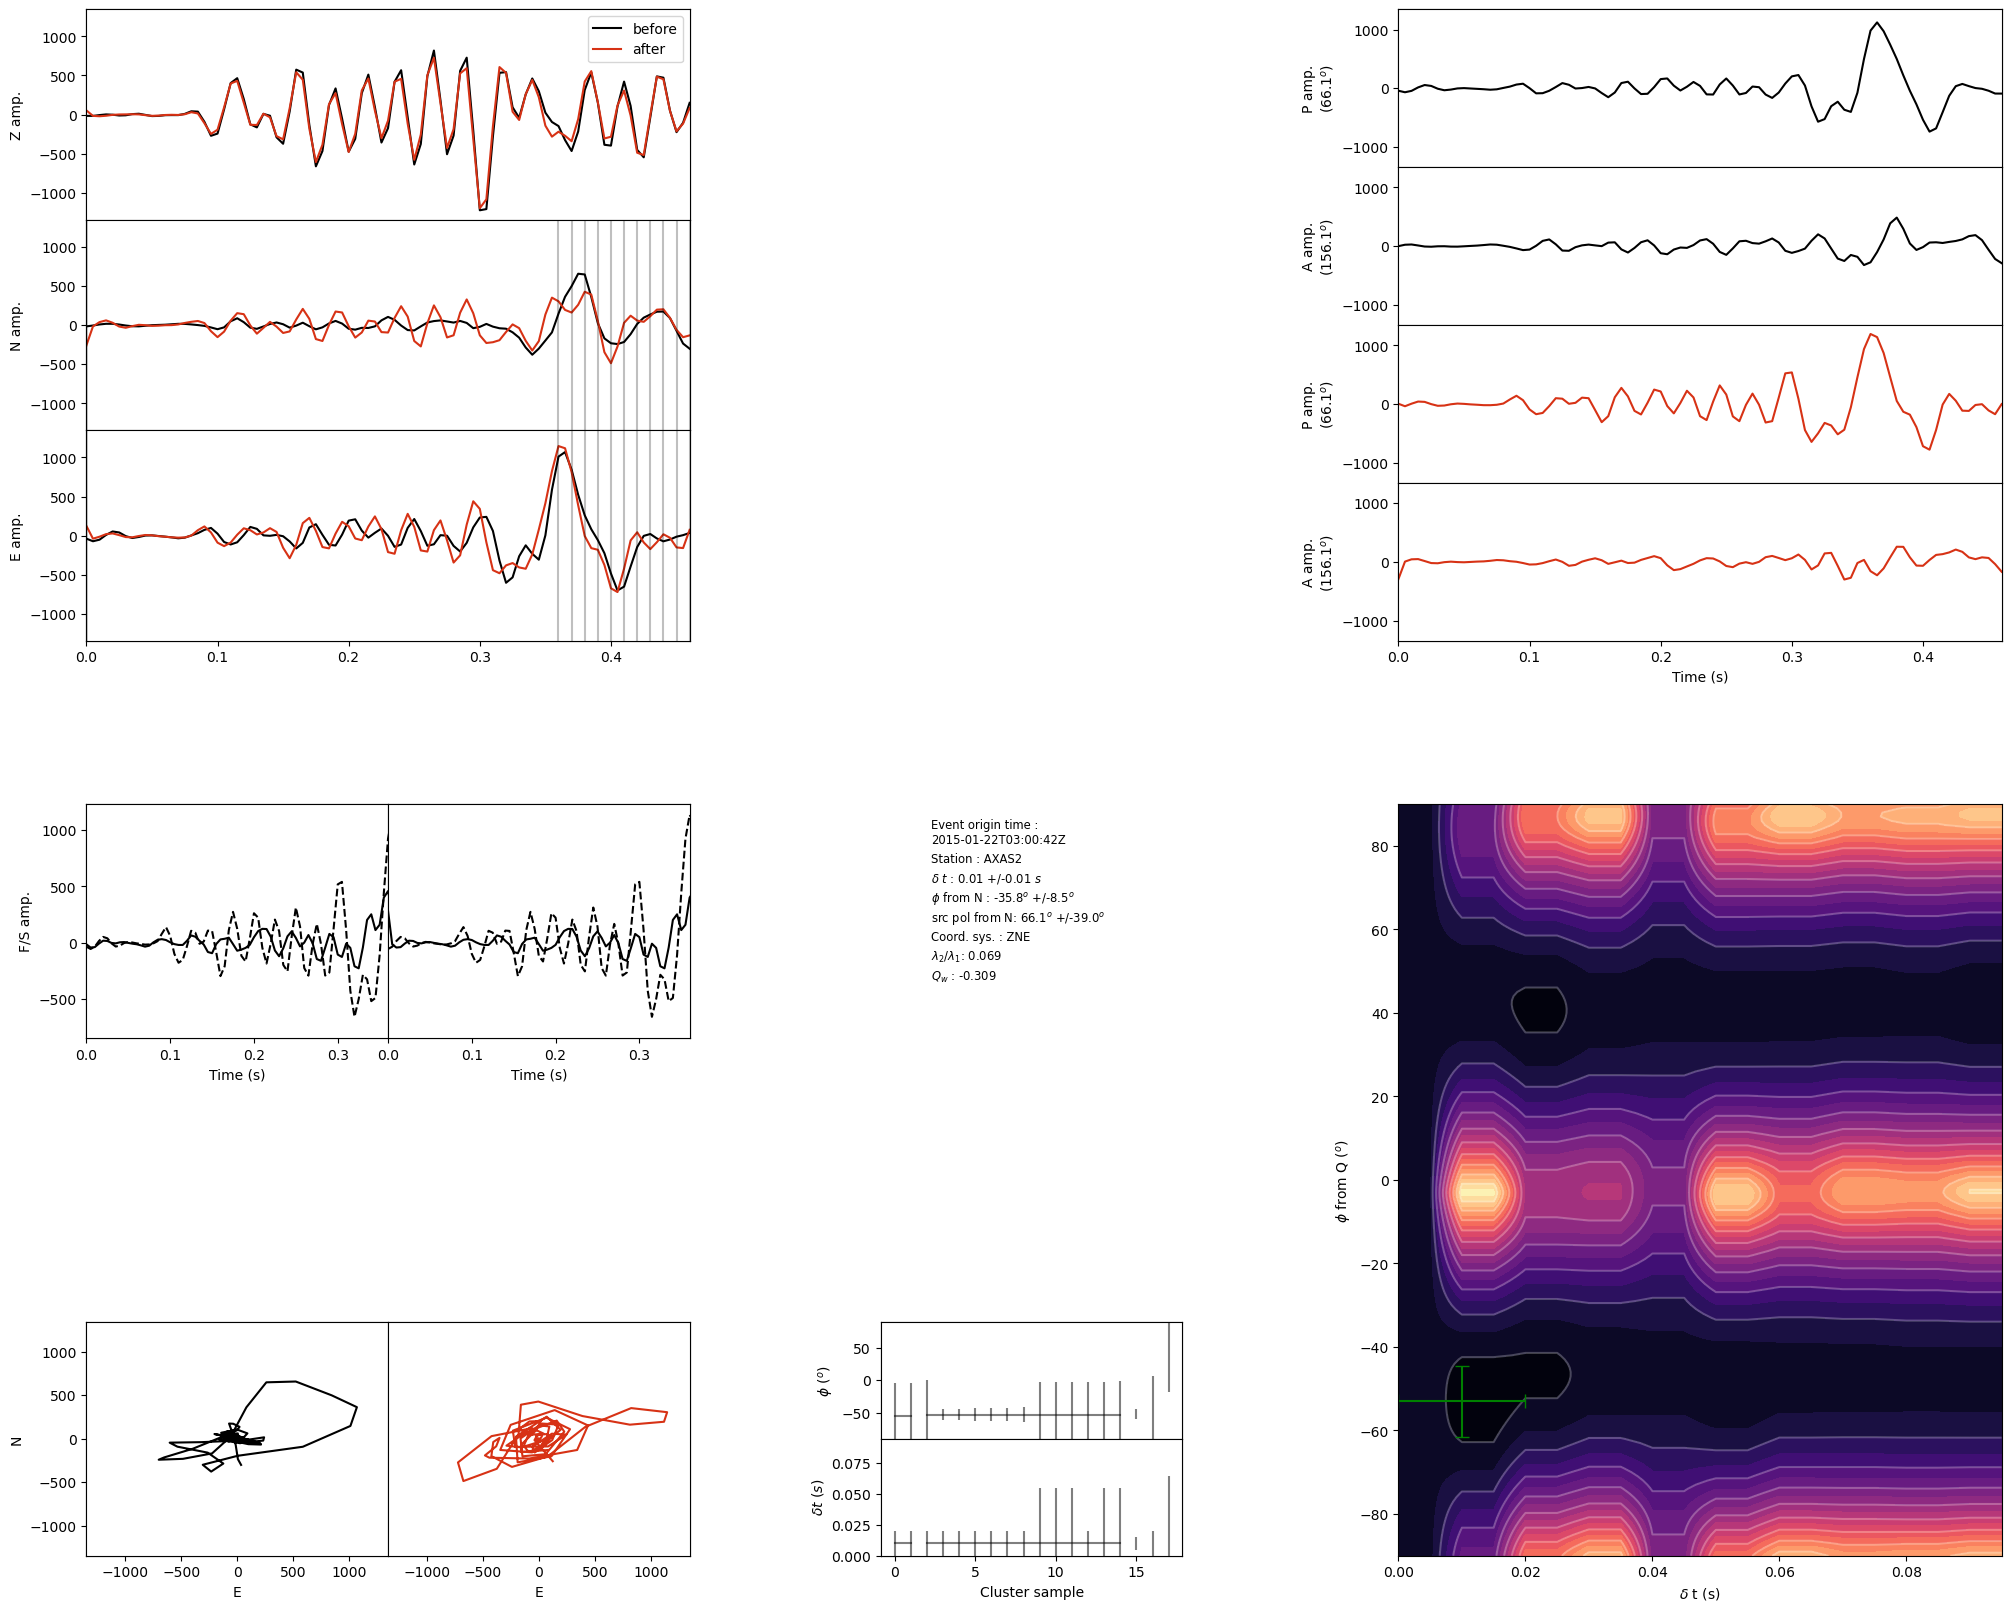

  ✓ Splitting analysis complete!
    Fast axis (φ): -35.8°
    Delay time (δt): 0.010s
  ✓ SUCCESS!
    Fast axis (φ): -35.8°
    Delay time (δt): 0.010s
    φ error: ±8.5°
    δt error: ±0.010s

Splitting Analysis Summary
Total events processed: 1
Successful splits: 1 (100.0%)

Failure breakdown:
  Missing components: 0
  Missing back-azimuth: 0
  Splitting errors: 0

────────────────────────────────────────────────────────────
Splitting Parameter Statistics
────────────────────────────────────────────────────────────
Fast axis direction (φ):
  Mean: -35.8° ± 0.0°
  Range: -35.8° to -35.8°
  Median: -35.8°

Delay time (δt):
  Mean: 0.010 ± 0.000s
  Range: 0.010s to 0.010s
  Median: 0.010s


In [78]:
# Shear-wave splitting analysis using dynamic splitting parameters
print("Performing shear-wave splitting analysis using SWSPy...")
results = perform_splitting_on_organized_waveforms(passing_waveforms, use_dynamic_params=False)

## 7. Visualization and Interpretation
- This section takes our results and makes a new dataframe of phi_from_N, phi_err, dt, dt_err, and datetime for each event.
- This section also plots fast direction (in +/- 0.2 radians) over time (+/- 24 hours 22:30 UTC April 23, 2015), with a colorbar representing confidence using phi_err (a 2D histogram), and in a second plot, lag time in seconds over the same time scales, also as a 2D histogram representing confidence

In [79]:
# Create results dataframe with splitting parameters
print("Creating results dataframe from splitting analysis...")

# Initialize lists to store results
event_ids = []
datetimes = []
phi_values = []
phi_errors = []
dt_values = []
dt_errors = []

# Extract results from the splitting analysis
for event_id, result_data in results.items():
    if 'result' in result_data and result_data['result'] is not None:
        result = result_data['result']
        
        # Get datetime from passing_waveforms
        if event_id in passing_waveforms:
            datetime_str = passing_waveforms[event_id]['datetime']
            
            event_ids.append(event_id)
            datetimes.append(datetime_str)
            phi_values.append(result.get('phi', np.nan))
            phi_errors.append(result.get('phi_error', np.nan))
            dt_values.append(result.get('dt', np.nan))
            dt_errors.append(result.get('dt_error', np.nan))

# Create dataframe
results_df = pd.DataFrame({
    'event_id': event_ids,
    'datetime': datetimes,
    'phi_from_N': phi_values,
    'phi_error': phi_errors,
    'dt': dt_values,
    'dt_error': dt_errors
})

# Convert datetime strings to datetime objects
results_df['datetime'] = pd.to_datetime(results_df['datetime'])

print(f"Created results dataframe with {len(results_df)} measurements")
print("\nSample results:")
display(results_df.head())

Creating results dataframe from splitting analysis...
Created results dataframe with 1 measurements

Sample results:


,event_id,datetime,phi_from_N,phi_error,dt,dt_error
0,6,2015-01-22 03:00:46.773000+00:00,-35.811777,8.5,0.01,0.01


In [80]:
results

{6: {'result': {'station': 'AXAS2',
   'phi': -35.8117771331525,
   'dt': 0.01,
   'phi_error': 8.5,
   'dt_error': 0.01,
   'snr_avg': 6.202451512790344,
   's_arrival_time': 0.592,
   'magnitude': 0.4,
   'filter_freq_min': 5.0,
   'filter_freq_max': 40.0,
   'window_duration': 1.0,
   'success': True,
   'sws_result_df':   station  phi_from_Q  phi_from_N  phi_from_U  phi_err    dt  dt_err  \
   0   AXAS2       -53.0  -35.811777   69.273789      8.5  0.01    0.01   
   
      src_pol_from_N  src_pol_from_U  src_pol_from_N_err  src_pol_from_U_err  \
   0        66.14102       174.92391           39.006244           84.732165   
   
           Q_w  lambda2/lambda1 ratio  ray_back_azi    ray_inc  
   0 -0.308607                0.06876    197.188223  20.726211  ,
   'event_id': 6,
   'back_azimuth': np.float64(197.1882228668475),
   'snr_horizontal': 6.202451512790344,
   'rectilinearity': np.float64(0.8758299422358464),
   'incidence': np.float64(20.726211035997288),
   'event_lat': 45.

In [81]:
# Show sample results
sample_event = list(results['result'].keys())[0]
sample_stations = results['result'][sample_event]
print(f"\nSample results for event {sample_event}:")

for station, result in sample_stations.items():
    print(f"  {station}: φ={result['phi']:.1f}°, δt={result['dt']:.3f}s")

KeyError: 'result'

In [82]:
# Probe into one specific event based on splitting results: is it a whale?
# Code 2015-01-22T03:10:01.000Z
# Event 1: 80
# Event 2: 314
event_id = 6

Selected event ID: {example_event_id}


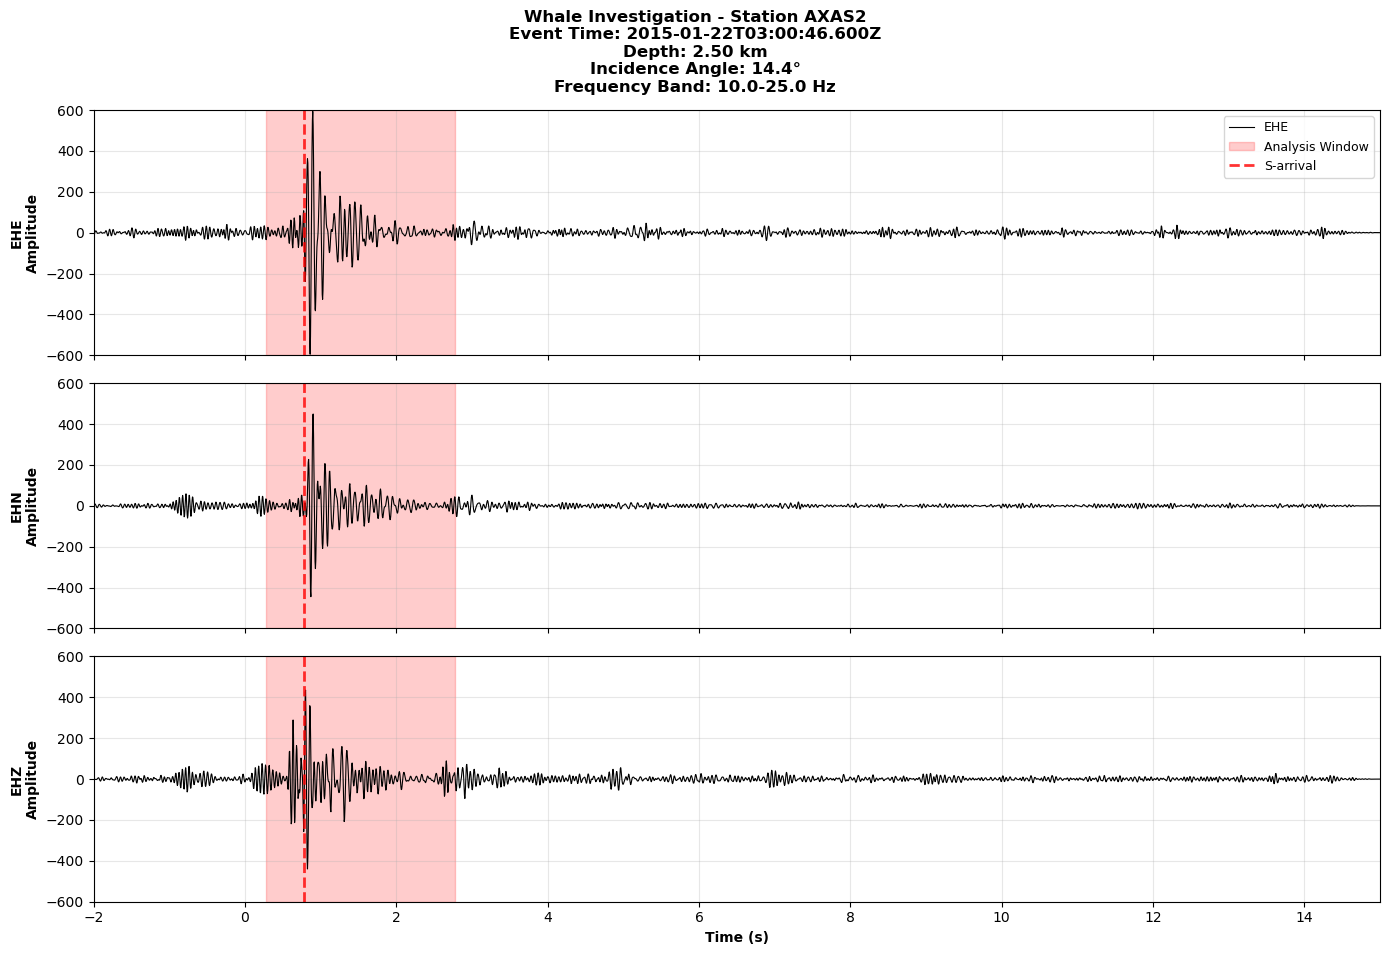

In [24]:


# Select an example from organized waveforms that passed quality control
example_data = passing_waveforms[event_id]

print("Selected event ID: {example_event_id}")

# Get the waveform traces
st = example_data['traces'].copy()

st = st.filter(type="bandpass", freqmin=10.0, freqmax= 25.0)
st = st.taper(type="hann", max_percentage=0.05)


# Plot the components
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Get S-wave arrival time relative to trace start
s_time_rel = example_data.get('s_arrival_time')

# Plot each component
for i, tr in enumerate(st.sort(['channel'])):
    ax = axes[i]
    
    # Filter for display
    trace_start = st[0].stats.starttime
    origin_time = UTCDateTime(example_data.get('origin_time'))
    time_offset = float(trace_start - origin_time)  # Should be -4.0 seconds
    time = tr.times() + time_offset  # Convert to origin-relative time
    
    # Plot waveform
    ax.plot(time, tr.data, 'k', linewidth=0.8, label=tr.stats.channel)
    ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Highlight S-wave analysis window
    window_start = s_time_rel - 0.5
    window_end = s_time_rel + 2.0
    ax.axvspan(window_start, window_end, alpha=0.2, color='red', 
                label='Analysis Window' if i == 0 else '')
    
    # Add S-wave arrival marker
    ax.axvline(s_time_rel, color='red', linestyle='--', alpha=0.8, 
                linewidth=2, label='S-arrival' if i == 0 else '')
    
    # Set limits and formatting
    ax.set_xlim([-2, 15])
    ylim = np.max(np.abs(tr.data))
    ax.set_ylim(-600,600)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (s)', fontweight='bold')

# Title
title = (f"Whale Investigation - Station {example_data['station']}\n"
        f"Event Time: {example_data['datetime']}\n"
        f"Depth: {example_data['depth']:.2f} km\n"
        f"Incidence Angle: {example_data['incidence']:.1f}°\n"
        f"Frequency Band: 10.0-25.0 Hz")

fig.suptitle(title, fontsize=12, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

print()

In [83]:
# Compare output of first AXAS2 event vs. Christian's results. Problem - there are like 12 other passing events in Christian's code before my first event! 
# Too many events getting skipped

event_id = 6

Selected event ID: {example_event_id}


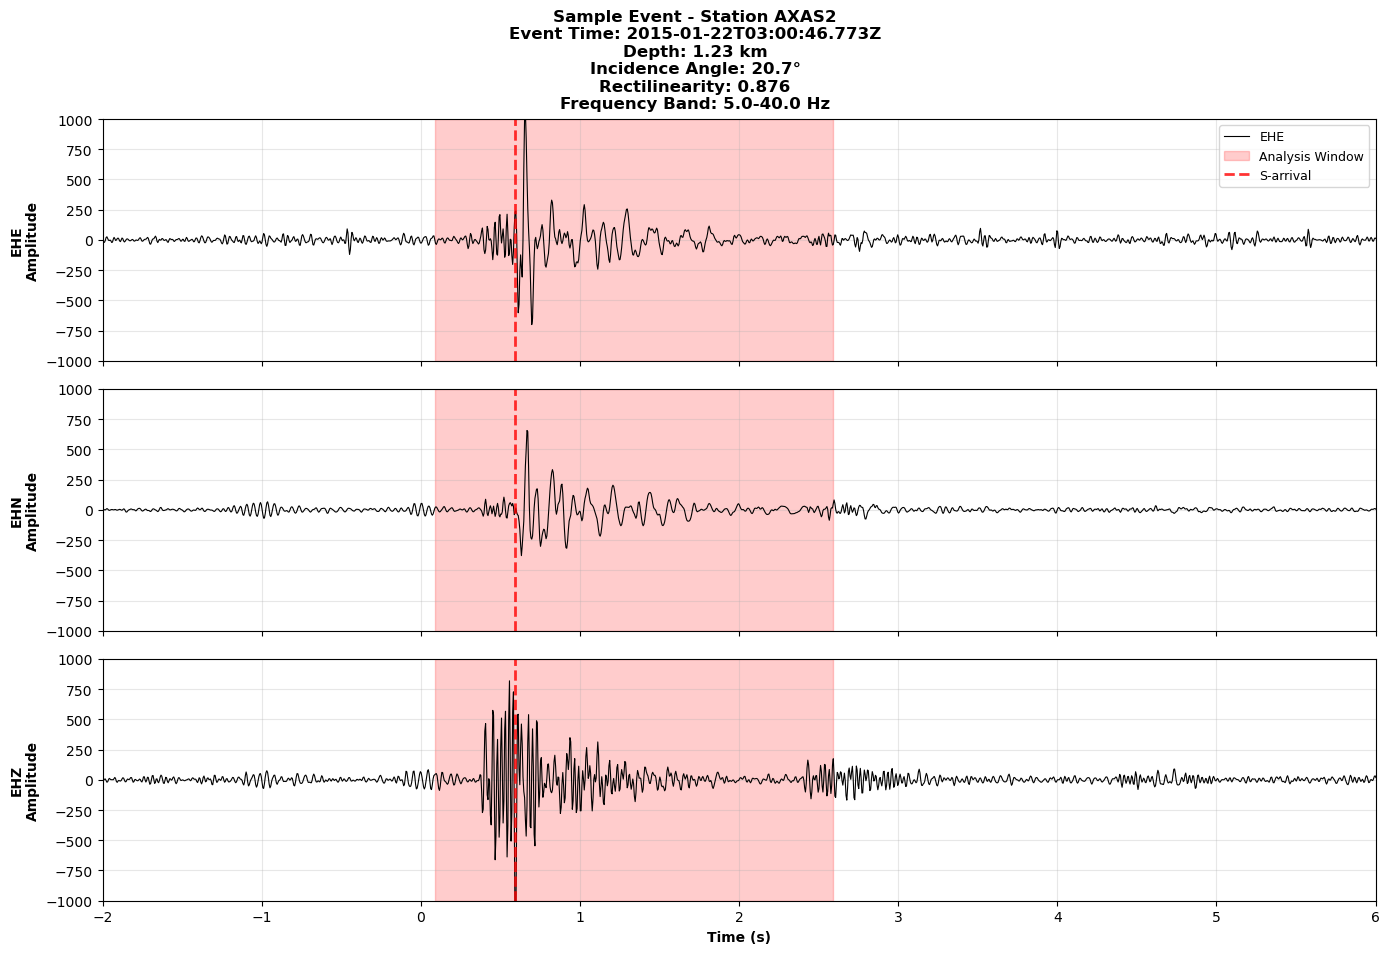

In [ ]:
# Select an example from organized waveforms that passed quality control
example_data = passing_waveforms[event_id]

print("Selected event ID: {example_event_id}")

# Get the waveform traces
st = example_data['traces'].copy()

st = st.filter(type="bandpass", freqmin=5.0, freqmax= 40.0)
st = st.taper(type="hann", max_percentage=0.05)


# Plot the components
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Get S-wave arrival time relative to trace start
s_time_rel = example_data.get('s_arrival_time')

# Plot each component
for i, tr in enumerate(st.sort(['channel'])):
    ax = axes[i]
    
    # Filter for display
    trace_start = st[0].stats.starttime
    origin_time = UTCDateTime(example_data.get('origin_time'))
    time_offset = float(trace_start - origin_time)  # Should be -4.0 seconds
    time = tr.times() + time_offset  # Convert to origin-relative time
    
    # Plot waveform
    ax.plot(time, tr.data, 'k', linewidth=0.8, label=tr.stats.channel)
    ax.set_ylabel(f"{tr.stats.channel}\nAmplitude", fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Highlight S-wave analysis window
    window_start = s_time_rel - 0.5
    window_end = s_time_rel + 2.0
    ax.axvspan(window_start, window_end, alpha=0.2, color='red', 
                label='Analysis Window' if i == 0 else '')
    
    # Add S-wave arrival marker
    ax.axvline(s_time_rel, color='red', linestyle='--', alpha=0.8, 
                linewidth=2, label='S-arrival' if i == 0 else '')
    
    # Set limits and formatting
    ax.set_xlim([-2, 6])
    ylim = np.max(np.abs(tr.data))
    ax.set_ylim(-1000,1000)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (s)', fontweight='bold')

# Title
title = (f"Sample Event - Station {example_data['station']}\n"
        f"Event Time: {example_data['datetime']}\n"
        f"Depth: {example_data['depth']:.2f} km\n"
        f"Incidence Angle: {example_data['incidence']:.1f}°\n"
        f"Rectilinearity: {example_data['rectilinearity']:.3f}\n"
        f"Frequency Band: 5.0-40.0 Hz")

fig.suptitle(title, fontsize=12, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.84)
plt.show()

print()

In [28]:
# Print out rectilinearity, SNR, and incidence angle for the selected event
print(f"Event: {example_data['station']} at {example_data['datetime']}")
print()
print("My results:")
print(f"Rectilinearity: {example_data['rectilinearity']:.3f}")
print(f"SNR: {example_data['snr_horizontal']:.2f}")
print(f"Incidence Angle: {example_data['incidence']:.1f}°")
print(f"S-pick Time: {(UTCDateTime(example_data['datetime']) + timedelta(seconds=example_data['s_arrival_time']))}")
print(f"Fast Direction: -0.3° from N")
print(f"Delay Time: 0.04s")
print()
print("Christian's results:")
print("Rectilinearity: 0.965")
print("SNR: 3.77")
print("Incidence Angle: 11.9°")
print("S-pick Time: 2015-01-22T10:15:32.750000Z")
print(f"Fast Direction: {np.rad2deg(0.73):.1f}° from N")



Event: AXAS2 at 2015-01-22T03:21:07.700Z

My results:
Rectilinearity: 0.837
SNR: 5.37
Incidence Angle: 14.5°
S-pick Time: 2015-01-22T03:21:08.240000Z
Fast Direction: -0.3° from N
Delay Time: 0.04s

Christian's results:
Rectilinearity: 0.965
SNR: 3.77
Incidence Angle: 11.9°
S-pick Time: 2015-01-22T10:15:32.750000Z
Fast Direction: 41.8° from N


In [72]:
example_data

{'traces': 3 Trace(s) in Stream:
OO.AXAS2..EHE | 2015-01-22T10:15:28.090000Z - 2015-01-22T10:15:47.090000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHN | 2015-01-22T10:15:28.090000Z - 2015-01-22T10:15:47.090000Z | 200.0 Hz, 3801 samples
OO.AXAS2..EHZ | 2015-01-22T10:15:28.090000Z - 2015-01-22T10:15:47.090000Z | 200.0 Hz, 3801 samples,
 'origin_time': 2015-01-22T10:15:32.090000Z,
 'datetime': '2015-01-22T10:15:32.090Z',
 'starttime': 2015-01-22T10:15:28.090000Z,
 'endtime': 2015-01-22T10:15:47.090000Z,
 'pre_event_sec': 4.0,
 'post_event_sec': 15.0,
 'magnitude': 0.0,
 'depth': 1.42,
 'latitude': 45.9432,
 'longitude': -130.0193,
 'station': 'AXAS2',
 'p_arrival_time': 0.44,
 's_arrival_time': 0.71,
 'snr_e': 2.9401425349415,
 'snr_n': 5.347135286623701,
 'snr_horizontal': 4.143638910782601,
 'back_azimuth': np.float64(328.68219995761575),
 'rectilinearity': np.float64(0.7071041791507646),
 'incidence': np.float64(19.870581581087276)}

In [50]:
trace = st.traces

In [59]:
tr = trace[0]

In [60]:
tr.stats.channel[-1].upper()

'E'